#  Telecom Customer Churn Prediction — Exploratory Data Analysis (EDA)

### Phase 2 : Exploratory Data Analysis

#### Importing Libraries

In [130]:
%cd "C:\Users\Lenovo\Desktop\github projects\telcos customer churn"

C:\Users\Lenovo\Desktop\github projects\telcos customer churn


In [131]:
import pandas as pd 
import numpy as np 

import matplotlib.pyplot as plt
import  seaborn as sns

from scipy import stats


from src.data_ingestion import DataIngestion

pd.set_option("display.max_columns",None)
sns.set_style("whitegrid")


#### Load Dataset 

In [132]:
ingestion=DataIngestion()
df=ingestion.load_data()
print(df.shape)

(7043, 21)


#### Clean Dataset fro EDA

In [133]:
## lets fix the data typesof total charges 

df["TotalCharges"]=df["TotalCharges"].replace(" ",np.nan)

df["TotalCharges"]=df["TotalCharges"].astype(float)

print(df["TotalCharges"].dtype)

float64


#### Check Missing values

In [134]:
missing_df=DataIngestion.dataset_summary(df)
missing_df[missing_df["Missing Values"]>0]

,Data Types,Missing Values,Missing Percentage,Unique Values
TotalCharges,float64,11,0.16,6530


#  Statistical Exploratory Data Analysis

#### Describe

In [135]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.00,0.000,0.0000,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.000,55.0000,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.350,89.8500,118.75
TotalCharges,7032.0,2283.300441,2266.771362,18.80,401.45,1397.475,3794.7375,8684.80


In [136]:
df.describe(include="object").T

,count,unique,top,freq
customerID,7043,7043,7590-VHVEG,1
gender,7043,2,Male,3555
Partner,7043,2,No,3641
Dependents,7043,2,No,4933
PhoneService,7043,2,Yes,6361
MultipleLines,7043,3,No,3390
InternetService,7043,3,Fiber optic,3096
OnlineSecurity,7043,3,No,3498
OnlineBackup,7043,3,No,3088
DeviceProtection,7043,3,No,3095


#### Skewness

In [137]:
numerical_features=["tenure","MonthlyCharges", "TotalCharges"]

skew_df=pd.DataFrame({"Skewness":df[numerical_features].skew()})
skew_df

,Skewness
tenure,0.239540
MonthlyCharges,-0.220524
TotalCharges,0.961642


####  Kurtosis

In [138]:
kurtosis_df=pd.DataFrame({"Kurtosis":df[numerical_features].kurtosis()})
kurtosis_df

,Kurtosis
tenure,-1.387372
MonthlyCharges,-1.257260
TotalCharges,-0.231799


#### Missing Value Summary

In [139]:
missing_df

,Data Types,Missing Values,Missing Percentage,Unique Values
customerID,object,0,0.00,7043
gender,object,0,0.00,2
SeniorCitizen,int64,0,0.00,2
Partner,object,0,0.00,2
Dependents,object,0,0.00,2
tenure,int64,0,0.00,73
PhoneService,object,0,0.00,2
MultipleLines,object,0,0.00,3
InternetService,object,0,0.00,3
OnlineSecurity,object,0,0.00,3


#### Duplicate Summary

In [140]:
print(f"Duplicate Rows :{df.duplicated().sum()}")

Duplicate Rows :0


In [141]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"]=(8,5)
plt.rcParams["axes.titlesize"]=16
plt.rcParams["axes.titleweight"]="bold"
plt.rcParams["axes.labelsize"]=12
plt.rcParams["xtick.labelsize"]=10
plt.rcParams["ytick.labelsize"]=10


# Univariate Analysis

## Visualization 1 — Customer Churn Distribution

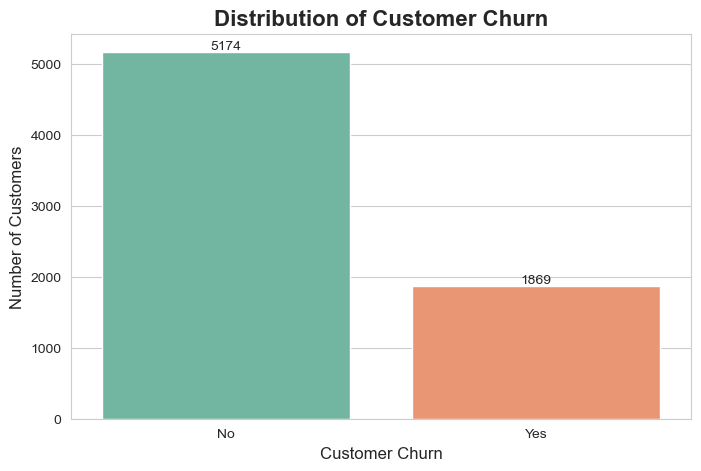

In [142]:
ax=sns.countplot(data=df,x="Churn",hue="Churn",palette="Set2",legend=False)

for container in ax.containers:
    ax.bar_label(container)


plt.title("Distribution of Customer Churn")
plt.xlabel("Customer Churn")
plt.ylabel("Number of Customers")

plt.show()


## Visualization 2 — Gender Distribution

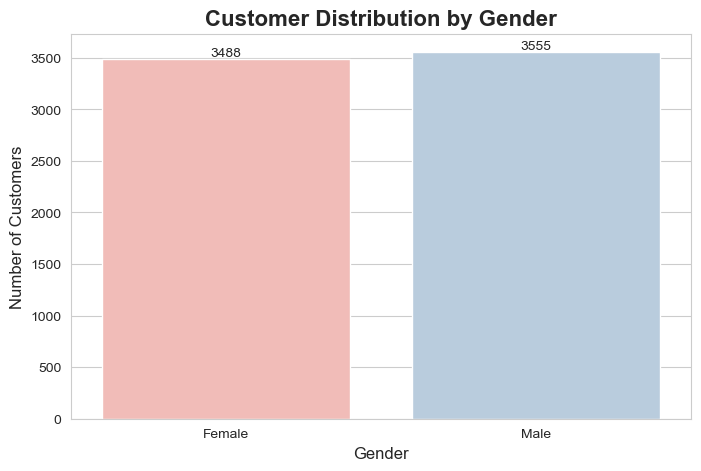

In [143]:
ax=sns.countplot(data=df,x="gender",hue="gender",palette="Pastel1",legend=False)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Customer Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

- Male and Female customers are almost equally distributed.
- Gender alone may not be a strong predictor of churn.

## Visualization 3 — Senior Citizen Distribution

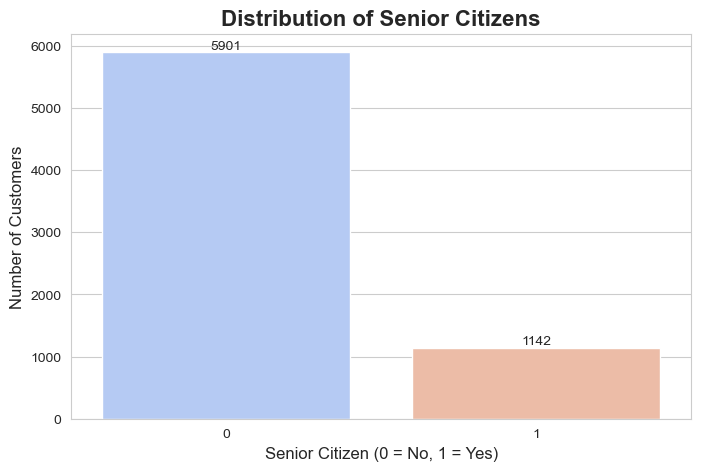

In [144]:
ax=sns.countplot(data=df,x="SeniorCitizen",hue="SeniorCitizen",palette="coolwarm",legend=False)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Distribution of Senior Citizens")
plt.xlabel("Senior Citizen (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")

plt.show()

- Senior citizens form a much smaller customer segment.
- We'll investigate whether this smaller group has a higher churn rate in the next section.

## Visualization 4 — Customers with Partners

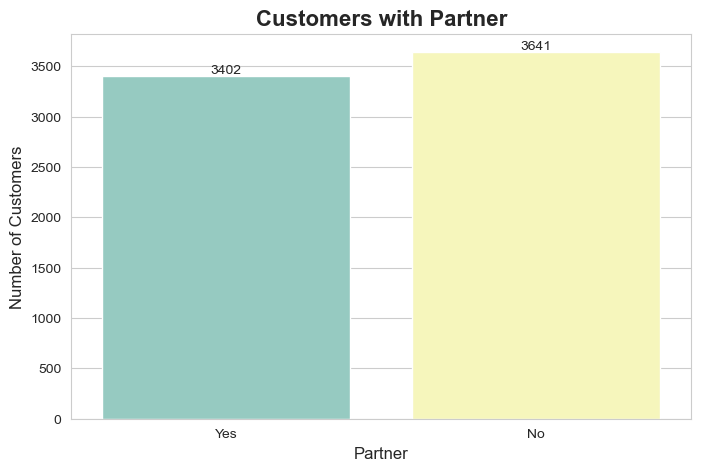

In [145]:
ax=sns.countplot(data=df,x="Partner",hue="Partner", palette="Set3",legend=False)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Customers with Partner")
plt.xlabel("Partner")
plt.ylabel("Number of Customers")

plt.show()

- Customers are fairly evenly divided between having a partner and not having a partner.

## Visualization 5 — Customers with Dependents

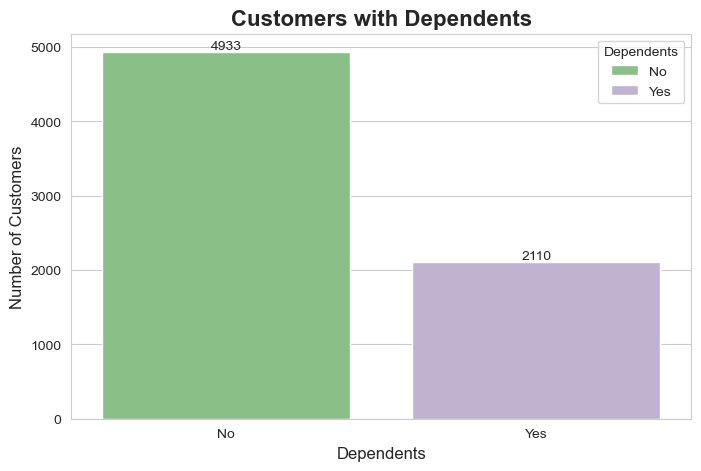

In [146]:
ax=sns.countplot(data=df,x="Dependents",hue="Dependents",palette="Accent",legend=True)


for container in ax.containers:
    ax.bar_label(container)

plt.title("Customers with Dependents")
plt.xlabel("Dependents")
plt.ylabel("Number of Customers")

plt.show()

- Most customers do not have dependents.

## Visualization 6 — Customer Tenure Distribution

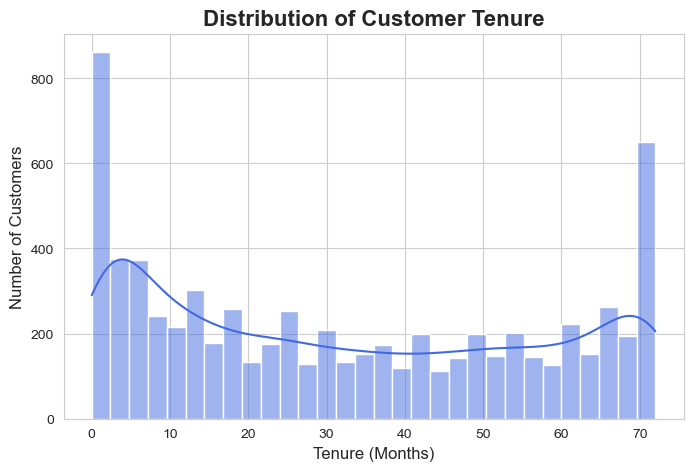

In [147]:
ax=sns.histplot(data=df, x="tenure",bins=30,kde=True,color="royalblue")
plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.show()

- A large number of customers have very low tenure.
- Another concentration exists among long-term customers.

## Visualization 7 — Monthly Charges Distribution

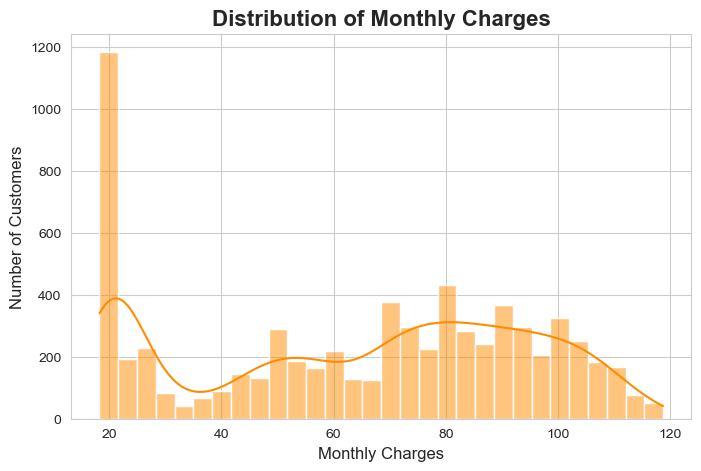

In [148]:
ax=sns.histplot(data=df,x="MonthlyCharges",bins=30,kde=True, color="darkorange")

plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")

plt.show()

- Monthly charges are not normally distributed.

## Visualization 8 — Total Charges Distribution

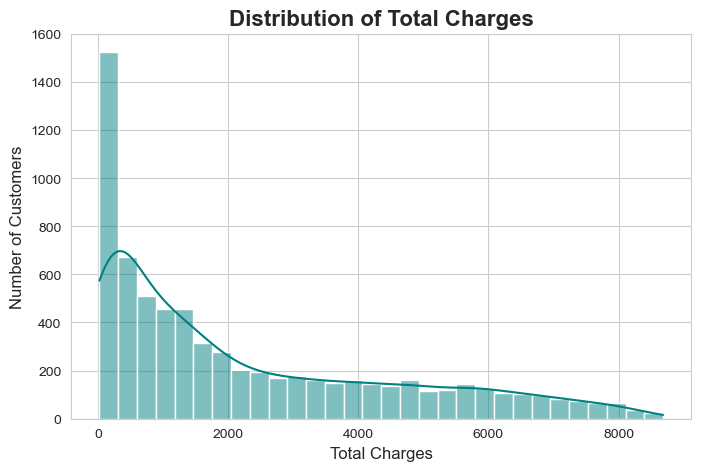

In [149]:
sns.histplot(data=df,x="TotalCharges",bins=30,kde=True,color="teal")

plt.title("Distribution of Total Charges")
plt.xlabel("Total Charges")
plt.ylabel("Number of Customers")

plt.show()


- Total charges are positively skewed.

## Visualization 9 — Contract Type Distribution

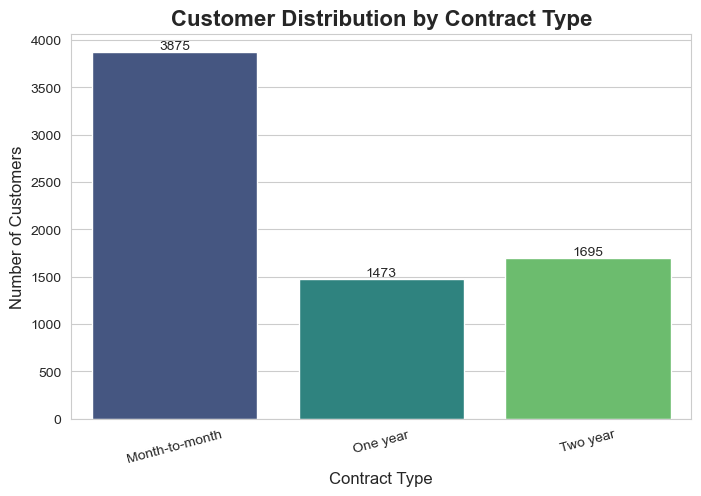

In [150]:
ax=sns.countplot(data=df,x="Contract",hue="Contract",palette="viridis",legend=False)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Customer Distribution by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.xticks(rotation=15)

plt.show()

- Month-to-Month contracts dominate the customer base.

## Visualization 10 — Internet Service Distribution

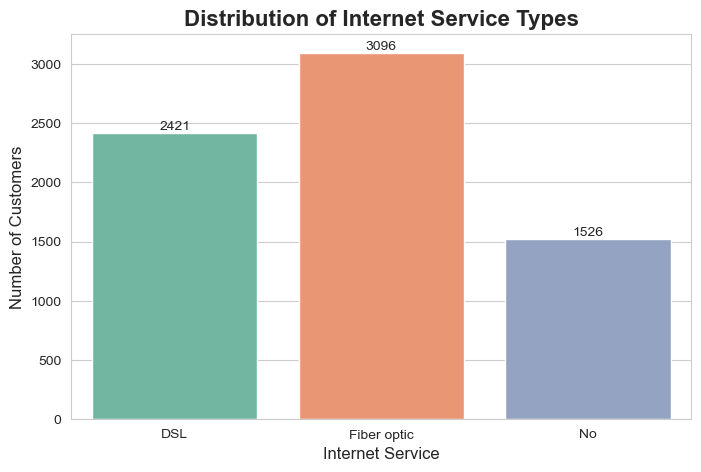

In [151]:
ax = sns.countplot(data=df,x="InternetService",hue="InternetService",palette="Set2",legend=False)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Distribution of Internet Service Types")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.show()

- Fiber Optic and DSL customers represent major internet segments.
- Customers without internet service form the smallest group.

#  Univariate Analysis Summary

In [152]:

pd.set_option("display.max_colwidth", None)
univariate_summary=pd.DataFrame({"Feature":["Churn","Gender","SeniorCitizen","Partner","Dependents","Tenure","MonthlyCharges", "TotalCharges","Contract","InternetService"],
                                 "Key Observation":["Dataset is moderately imbalanced (73% vs 27%).",
                                                    "Male and Female customers are almost equally distributed.",
        "Senior citizens are a smaller customer segment.","Partner distribution is fairly balanced.",
        "Most customers do not have dependents.","Tenure shows many new and many loyal customers.",
        "Monthly charges have multiple billing clusters.","Total charges are positively skewed.",
        "Month-to-Month contracts dominate.","Fiber Optic and DSL are the major internet services."]})

univariate_summary

,Feature,Key Observation
0,Churn,Dataset is moderately imbalanced (73% vs 27%).
1,Gender,Male and Female customers are almost equally distributed.
2,SeniorCitizen,Senior citizens are a smaller customer segment.
3,Partner,Partner distribution is fairly balanced.
4,Dependents,Most customers do not have dependents.
5,Tenure,Tenure shows many new and many loyal customers.
6,MonthlyCharges,Monthly charges have multiple billing clusters.
7,TotalCharges,Total charges are positively skewed.
8,Contract,Month-to-Month contracts dominate.
9,InternetService,Fiber Optic and DSL are the major internet services.


# Bivariate Analysis

#### Create helper function to avoid writing resuable code everyttime 

In [153]:
def churn_percentage(feature):
    churn_rate=(pd.crosstab(df[feature],df["Churn"],normalize="index")*100)

    churn_rate.plot(kind="bar",stacked=False,figsize=(8,5),colormap="Set2")
    plt.title(f"Customer Churn Percentage by {feature}")
    plt.ylabel("Percentage of Customers")
    plt.xlabel(feature)
    plt.legend(title="Churn")
    plt.xticks(rotation=15)

    plt.show()

## Visualization 1 — Gender vs Customer Churn

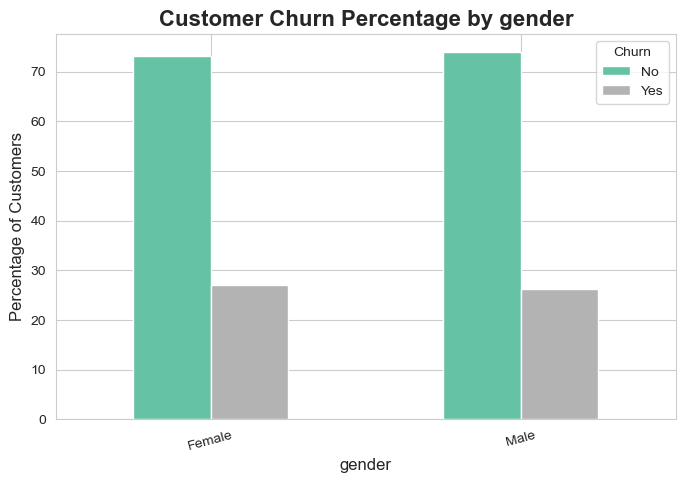

In [154]:
churn_percentage("gender")

- Male and Female customers have very similar churn percentages.
- Gender does not appear to be a strong churn driver

## Visualization 2 — Senior Citizen vs Customer Churn

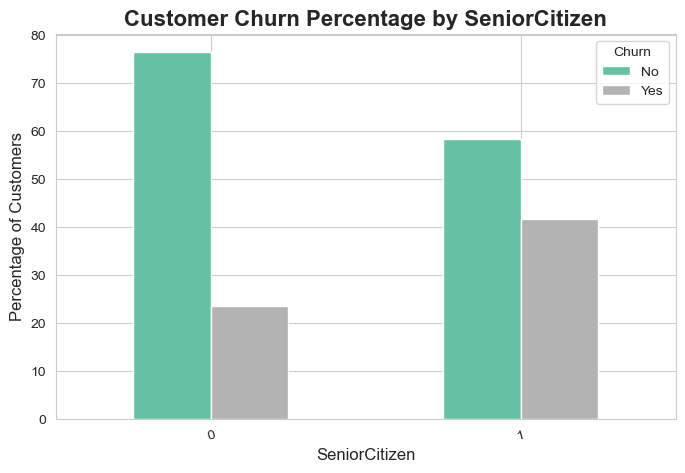

In [155]:
churn_percentage("SeniorCitizen")

- Senior citizens show a noticeably higher churn percentage.


## Visualization 3 — Partner vs Customer Churn

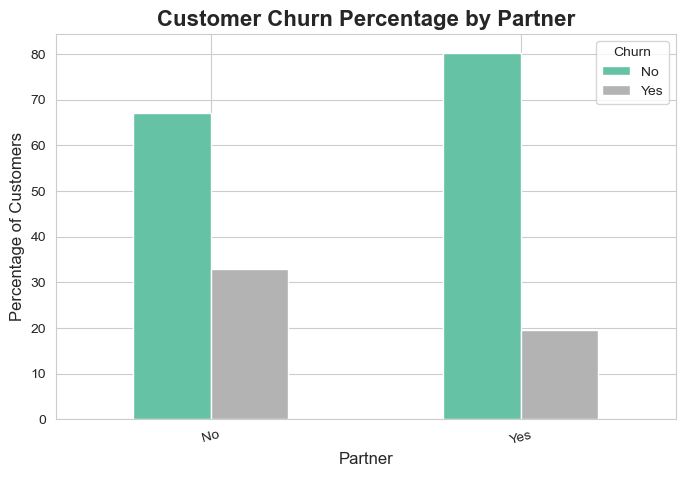

In [156]:
churn_percentage("Partner")

- Customers without partners churn more frequently.

## Visualization 4 — Dependents vs Customer Churn

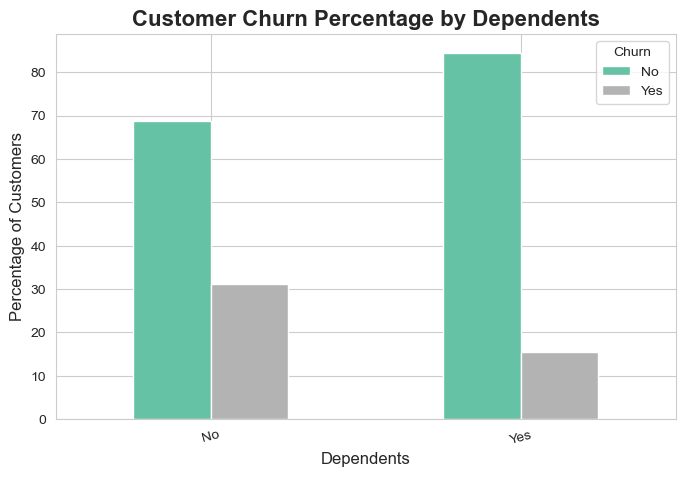

In [157]:
churn_percentage("Dependents")

- Customers with dependents churn much less frequently.

In [158]:
## Visualization 5 — Contract Type vs Customer Churn

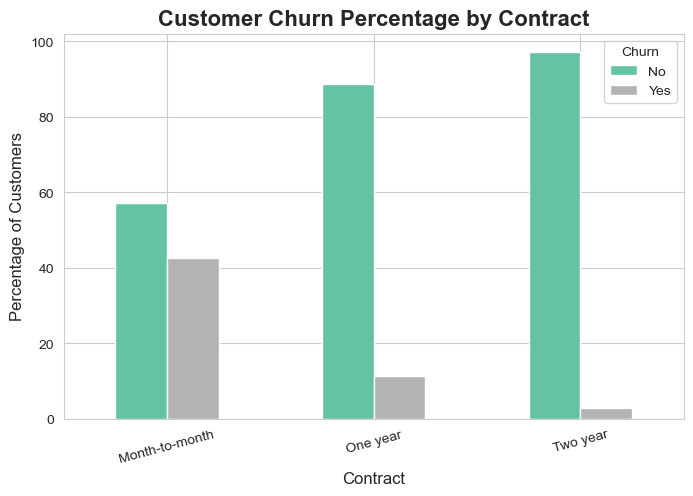

In [159]:
churn_percentage("Contract")

- Month-to-Month customers have the highest churn percentage.
- One-Year customers churn significantly less.
- Two-Year contract customers have the lowest churn rate.

## Visualization 6 — Internet Service vs Customer Churn

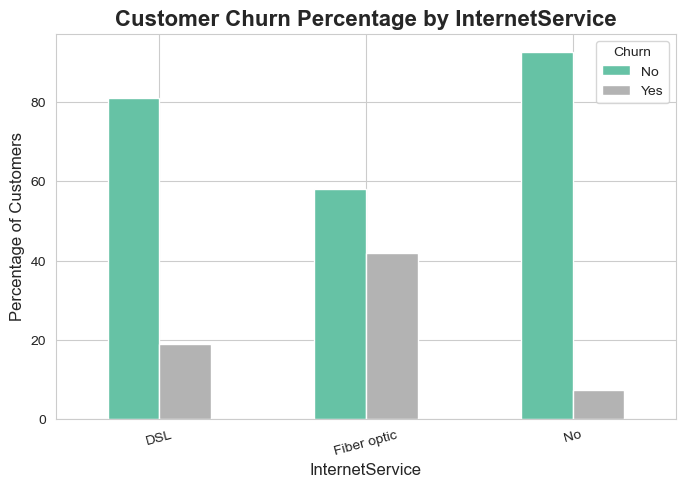

In [160]:
churn_percentage("InternetService")

- Fiber Optic customers have the highest churn percentage.
- DSL customers are comparatively more loyal.
- Customers without internet service churn the least.

## Visualization 7 — Payment Method vs Customer Churn

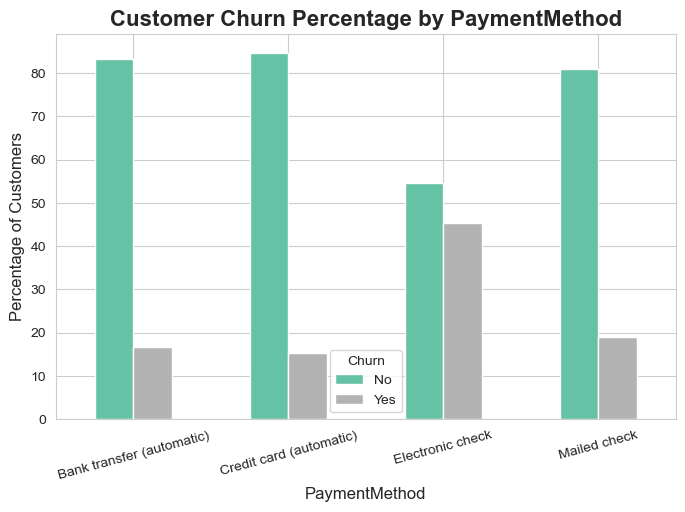

In [161]:
churn_percentage("PaymentMethod")


- Customers paying through **Electronic Check** churn the most.

## Visualization 8 — Paperless Billing vs Customer Churn

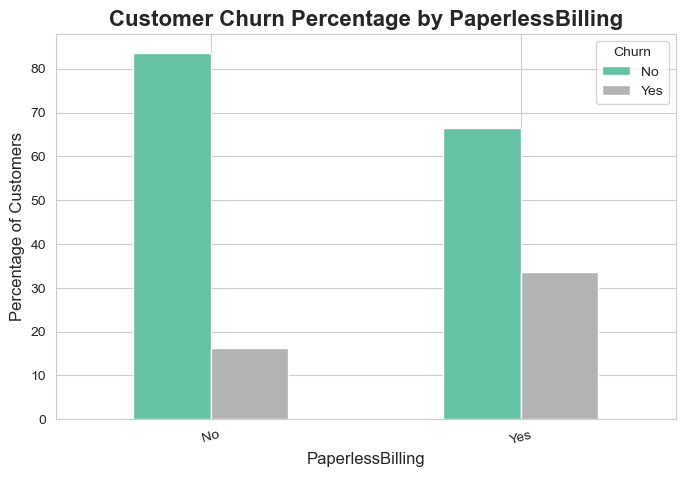

In [162]:
churn_percentage("PaperlessBilling")

- Customers using paperless billing churn more frequently.

## Visualization 9 — Customer Tenure vs Churn

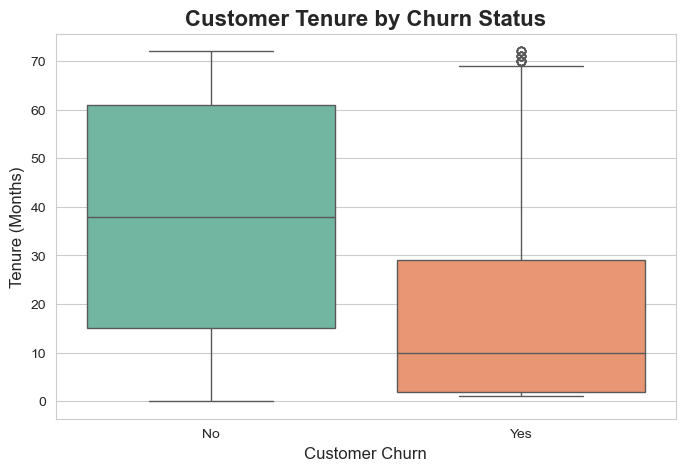

In [163]:
sns.boxplot(data=df,x="Churn",y="tenure",hue="Churn",palette="Set2",legend=False)

plt.title("Customer Tenure by Churn Status")
plt.xlabel("Customer Churn")
plt.ylabel("Tenure (Months)")

plt.show()

- Customers who churn generally have much lower tenure.
- Loyal customers stay significantly longer.

## Visualization 10 — Monthly Charges vs Churn

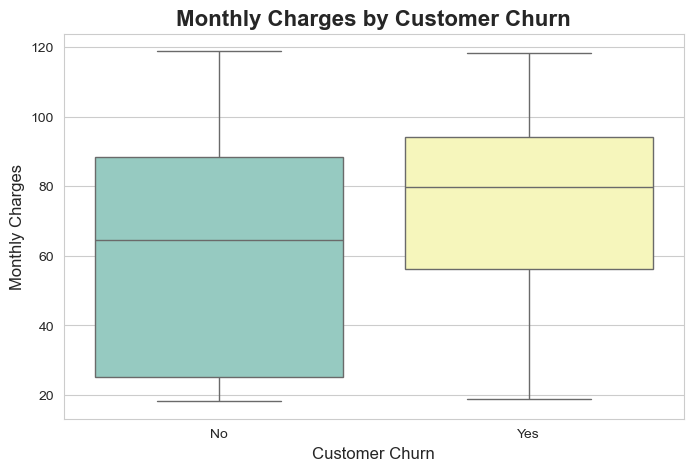

In [164]:
sns.boxplot(data=df,x="Churn",y="MonthlyCharges",hue="Churn",legend=False,palette="Set3")

plt.title("Monthly Charges by Customer Churn")
plt.xlabel("Customer Churn")
plt.ylabel("Monthly Charges")

plt.show()

- Customers with higher monthly charges show higher churn.
- Price sensitivity appears to influence churn behavior.

## Visualization 11 — Total Charges vs Customer Churn

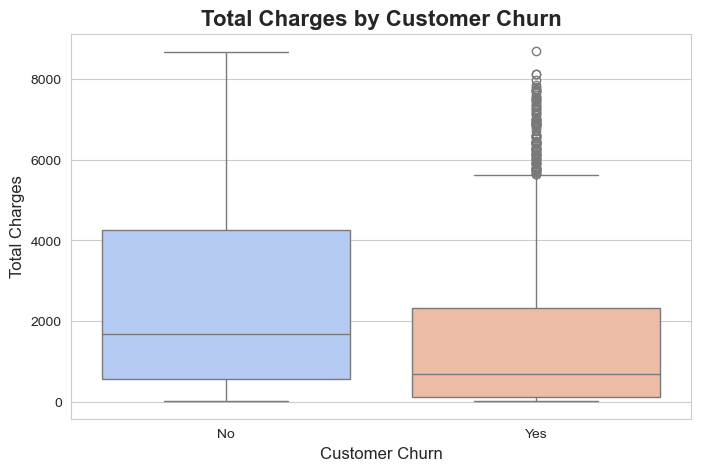

In [165]:
sns.boxplot(data=df,x="Churn",y="TotalCharges",hue="Churn",legend=False,palette="coolwarm")

plt.title("Total Charges by Customer Churn")
plt.xlabel("Customer Churn")
plt.ylabel("Total Charges")

plt.show()

- Churn customers generally have lower total charges because many leave early.

#  Churn Rate Summary by Business Features

In [166]:
features = [ "gender", "SeniorCitizen", "Partner","Dependents","Contract","InternetService","PaymentMethod", "PaperlessBilling"]

for feature in features:
    print("="*70)
    print(f"Churn Percentage by {feature}")
    print("="*70)

    
    display(
        (
            pd.crosstab(
                df[feature],
                df["Churn"],
                normalize="index"
            ) * 100
        ).round(2)
    )

   

Churn Percentage by gender


Churn,No,Yes
gender,,
Female,73.08,26.92
Male,73.84,26.16


Churn Percentage by SeniorCitizen


Churn,No,Yes
SeniorCitizen,,
0,76.39,23.61
1,58.32,41.68


Churn Percentage by Partner


...

Churn,No,Yes
InternetService,,
DSL,81.04,18.96
Fiber optic,58.11,41.89
No,92.60,7.40


Churn Percentage by PaymentMethod


Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.29,16.71
Credit card (automatic),84.76,15.24
Electronic check,54.71,45.29
Mailed check,80.89,19.11


Churn Percentage by PaperlessBilling


Churn,No,Yes
PaperlessBilling,,
No,83.67,16.33
Yes,66.43,33.57


In [167]:
bivariate_summary = pd.DataFrame({
    "Feature": [
        "Gender",
        "Senior Citizen",
        "Partner",
        "Dependents",
        "Contract Type",
        "Internet Service",
        "Payment Method",
        "Paperless Billing",
        "Tenure",
        "Monthly Charges"
    ],
    "EDA Finding": [
        "Minimal difference in churn.",
        "Higher churn among senior citizens.",
        "Customers without partners churn more.",
        "Customers without dependents churn more.",
        "Month-to-Month contracts have highest churn.",
        "Fiber Optic customers churn the most.",
        "Electronic Check customers churn the most.",
        "Paperless billing customers churn more.",
        "Short-tenure customers churn significantly more.",
        "Higher monthly charges increase churn risk."
    ]
})

bivariate_summary

,Feature,EDA Finding
0,Gender,Minimal difference in churn.
1,Senior Citizen,Higher churn among senior citizens.
2,Partner,Customers without partners churn more.
3,Dependents,Customers without dependents churn more.
4,Contract Type,Month-to-Month contracts have highest churn.
5,Internet Service,Fiber Optic customers churn the most.
6,Payment Method,Electronic Check customers churn the most.
7,Paperless Billing,Paperless billing customers churn more.
8,Tenure,Short-tenure customers churn significantly more.
9,Monthly Charges,Higher monthly charges increase churn risk.


In [168]:
from scipy.stats import chi2_contingency
from scipy.stats.contingency import association

import itertools


#  Multivariate Analysis

#### Correlation Heatmap (Numerical Features)

In [169]:
numerical_features=["SeniorCitizen","tenure","MonthlyCharges","TotalCharges"]

corelation_matrix= df[numerical_features].corr()
corelation_matrix

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,0.016567,0.220173,0.102411
tenure,0.016567,1.000000,0.247900,0.825880
MonthlyCharges,0.220173,0.247900,1.000000,0.651065
TotalCharges,0.102411,0.825880,0.651065,1.000000


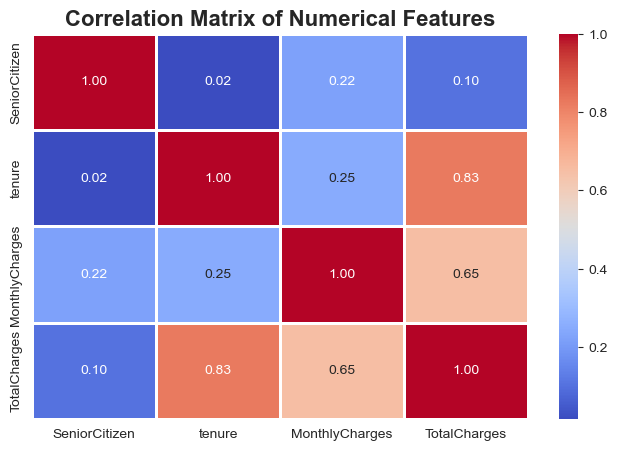

In [170]:
# heatmap
sns.heatmap(corelation_matrix, annot=True,cmap="coolwarm",linewidths=1,fmt=".2f")

plt.title("Correlation Matrix of Numerical Features")

plt.show()


- **TotalCharges** has a strong positive correlation with **tenure**.

#### Pairplot of Numerical Feature

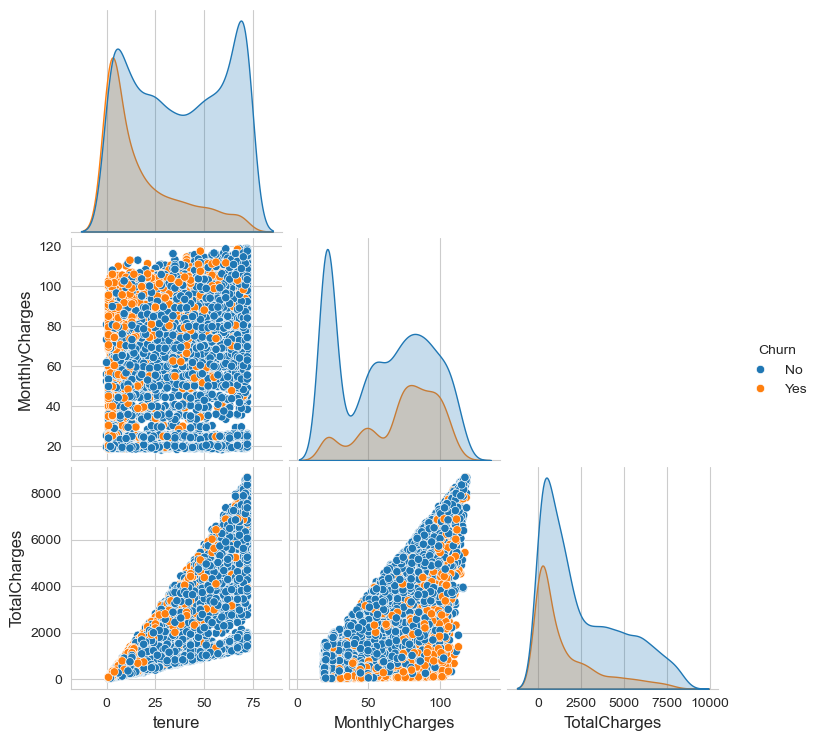

In [171]:
pairplot_df = df[[
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "Churn"
]]

sns.pairplot(pairplot_df,hue="Churn",diag_kind="kde",corner=True)
plt.show()


- Customers with low tenure cluster around churn.
- Long-tenure customers are mostly non-churn customers.
- High monthly charges combined with low tenure appear riskier.

#### Monthly Charges vs Tenure (Scatter Plot)

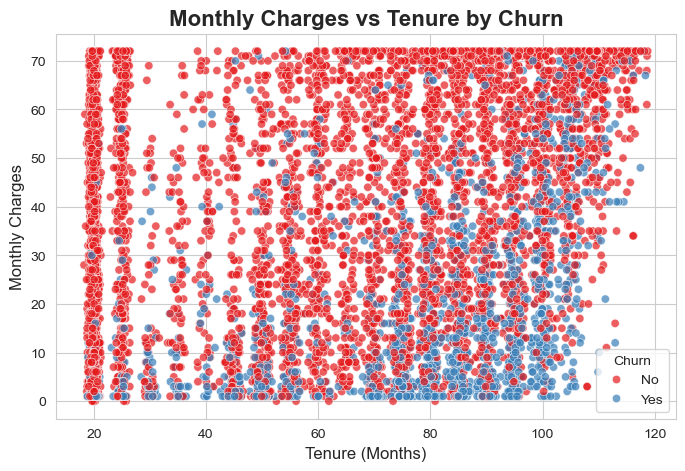

In [172]:
sns.scatterplot(data=df,x="MonthlyCharges",y="tenure",hue="Churn",palette="Set1",alpha=0.7)
plt.title("Monthly Charges vs Tenure by Churn")
plt.xlabel("Tenure (Months)")
plt.ylabel("Monthly Charges")

plt.show()

1. **Low Tenure + High Monthly Charges** → Highest churn risk.
2. **High Tenure + Moderate Monthly Charges** → Loyal customers.

#### Contract × Internet Service Heatmap

In [173]:
contract_internet=pd.crosstab([df["Contract"],df["InternetService"]],df["Churn"],normalize="index")*100
contract_internet=contract_internet.round(2)
contract_internet

Churn                              No    Yes
Contract       InternetService              
Month-to-month DSL              67.78  32.22
               Fiber optic      45.39  54.61
               No               81.11  18.89
One year       DSL              90.70   9.30
               Fiber optic      80.71  19.29
               No               97.53   2.47
Two year       DSL              98.09   1.91
               Fiber optic      92.77   7.23
               No               99.22   0.78

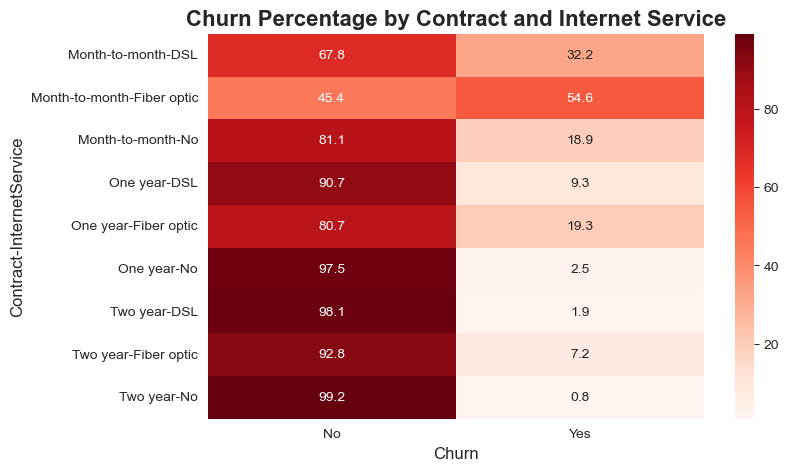

In [174]:
sns.heatmap(contract_internet,annot=True,cmap="Reds",fmt=".1f")

plt.title("Churn Percentage by Contract and Internet Service")

plt.show()

Highest churn combinations include:

- Month-to-Month + Fiber Optic.
- Month-to-Month + DSL.

Lowest churn combinations include:

- Two-Year + DSL.
- Two-Year + No Internet Service.

#### Churn Rate by Tenure Groups

In [175]:
df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[0,12,24,48,60,72],
    labels=[
        "0-12 Months",
        "13-24 Months",
        "25-48 Months",
        "49-60 Months",
        "61-72 Months"
    ]
)

df["TenureGroup"].head()

0     0-12 Months
1    25-48 Months
2     0-12 Months
3    25-48 Months
4     0-12 Months
Name: TenureGroup, dtype: category
Categories (5, object): ['0-12 Months' < '13-24 Months' < '25-48 Months' < '49-60 Months' < '61-72 Months']

In [176]:
tenure_group_churn=pd.crosstab(df["TenureGroup"],df["Churn"], normalize="index") * 100
tenure_group_churn


Churn,No,Yes
TenureGroup,,
0-12 Months,52.321839,47.678161
13-24 Months,71.289062,28.710938
25-48 Months,79.611041,20.388959
49-60 Months,85.576923,14.423077
61-72 Months,93.390192,6.609808


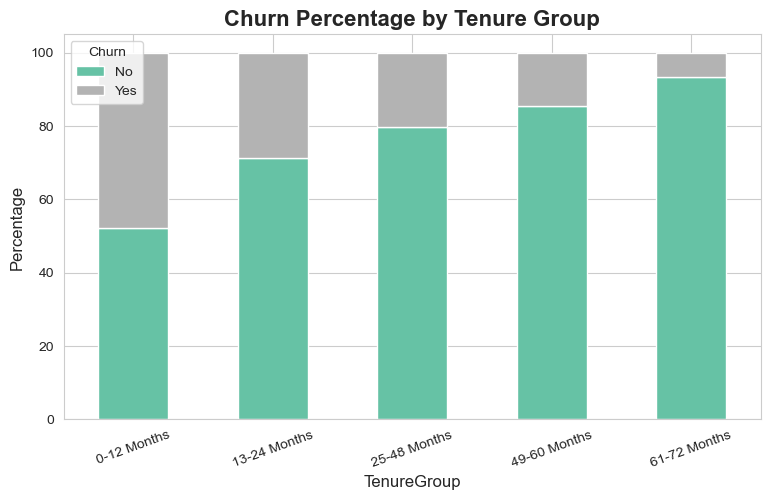

In [177]:
tenure_group_churn.plot( kind="bar",stacked=True,figsize=(9,5),colormap="Set2")

plt.title("Churn Percentage by Tenure Group")
plt.ylabel("Percentage")

plt.xticks(rotation=20)

plt.show()

- Customers within their first **12 months** have the highest churn.
- Churn decreases steadily as tenure increases.
- Customers staying longer than **48 months** are significantly more loyal.

#### Monthly Charges Groups vs Churn

In [178]:
df["MonthlyChargesGroup"]=pd.qcut(df["MonthlyCharges"],q=4,labels=["Low","Medium","High","Very High"])
df["MonthlyChargesGroup"].head()

0       Low
1    Medium
2    Medium
3    Medium
4      High
Name: MonthlyChargesGroup, dtype: category
Categories (4, object): ['Low' < 'Medium' < 'High' < 'Very High']

In [179]:
charge_group=pd.crosstab(df["MonthlyChargesGroup"],df["Churn"], normalize="index") * 100
charge_group

Churn,No,Yes
MonthlyChargesGroup,,
Low,88.762770,11.237230
Medium,75.424689,24.575311
High,62.492886,37.507114
Very High,67.121729,32.878271


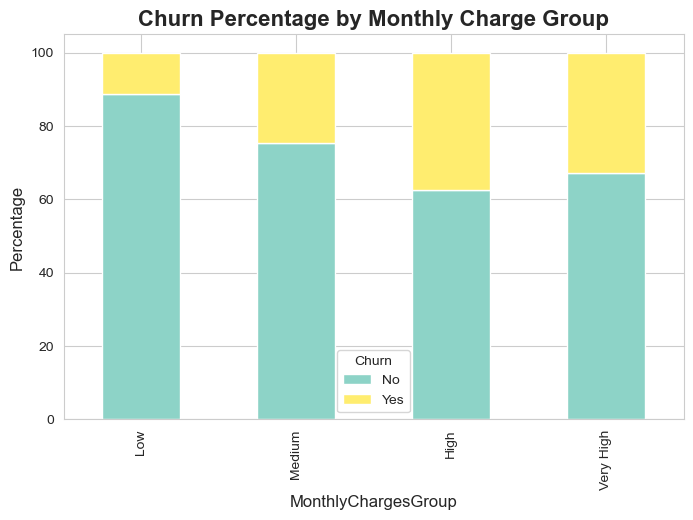

In [180]:
charge_group.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5),
    colormap="Set3"
)

plt.title("Churn Percentage by Monthly Charge Group")
plt.ylabel("Percentage")

plt.show()

- Churn increases as monthly charges increase.
- Very-high-paying customers represent an important churn-risk segment

#### Correlation of Numerical Features with Churn

In [181]:
df["ChurnBinary"]=df["Churn"].map({"No":0,"Yes":1})

target_corr= df.corr(numeric_only=True)["ChurnBinary"]

target_corr.sort_values(ascending=False)

target_corr

SeniorCitizen     0.150889
tenure           -0.352229
MonthlyCharges    0.193356
TotalCharges     -0.199484
ChurnBinary       1.000000
Name: ChurnBinary, dtype: float64

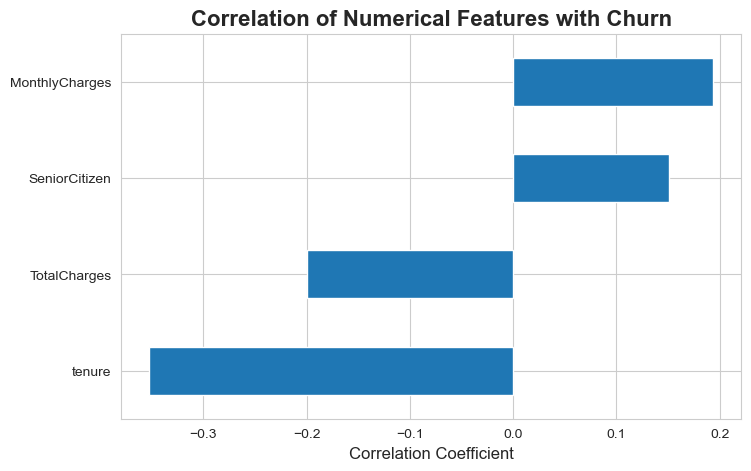

In [182]:
target_corr.drop("ChurnBinary").sort_values().plot(
    kind="barh"
)

plt.title("Correlation of Numerical Features with Churn")

plt.xlabel("Correlation Coefficient")

plt.show()

MonthlyCharges → Positive relationship with churn.
- SeniorCitizen → Mild positive relationship.
- Tenure → Strong negative relationship.
- TotalCharges → Negative relationship because loyal customers accumulate more spending.

#### Cramér's V Correlation Matrix

In [183]:
from scipy.stats.contingency import association
categorical_features = [
    "gender", "Partner", "Dependents", "PhoneService",
    "InternetService", "Contract", "PaymentMethod",
    "PaperlessBilling", "Churn"
]

cramers_matrix=pd.DataFrame(index=categorical_features,columns=categorical_features)
for col1 in categorical_features:
    for col2 in categorical_features:
        table = pd.crosstab(df[col1], df[col2])
        cramers_matrix.loc[col1, col2] = association(table, method="cramer")

cramers_matrix = cramers_matrix.astype(float)
cramers_matrix

,gender,Partner,Dependents,PhoneService,InternetService,Contract,PaymentMethod,PaperlessBilling,Churn
gender,1.000000,0.001808,0.010517,0.006488,0.011320,0.008153,0.018646,0.011754,0.008612
Partner,0.001808,1.000000,0.452676,0.017706,0.000907,0.296039,0.162762,0.014877,0.150448
Dependents,0.010517,0.452676,1.000000,0.001762,0.180267,0.244212,0.150744,0.111377,0.164221
PhoneService,0.006488,0.017706,0.001762,1.000000,0.452425,0.003976,0.010297,0.016505,0.011942
InternetService,0.011320,0.000907,0.180267,0.452425,1.000000,0.206921,0.313123,0.378427,0.322455
Contract,0.008153,0.296039,0.244212,0.003976,0.206921,1.000000,0.266655,0.177645,0.410116
PaymentMethod,0.018646,0.162762,0.150744,0.010297,0.313123,0.266655,1.000000,0.248719,0.303359
PaperlessBilling,0.011754,0.014877,0.111377,0.016505,0.378427,0.177645,0.248719,1.000000,0.191825
Churn,0.008612,0.150448,0.164221,0.011942,0.322455,0.410116,0.303359,0.191825,1.000000


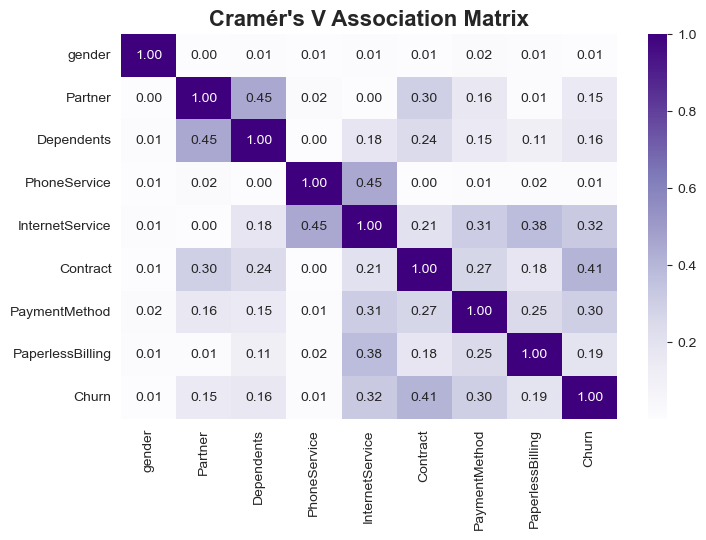

In [184]:
sns.heatmap(
    cramers_matrix,
    annot=True,
    cmap="Purples",
    fmt=".2f"
)

plt.title("Cramér's V Association Matrix")

plt.show()

Strong categorical associations appear between:

- Internet Service and Contract.
- Contract and Churn.
- Payment Method and Contract.

#### Chi-Square Test of Independence

In [185]:
chi_features = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "InternetService",
    "Contract",
    "PaymentMethod",
    "PaperlessBilling"
]

chi_results=[]

for feature in chi_features:
    contingency_table=pd.crosstab(df[feature],df["Churn"])

    chi2,p,dof,expected=chi2_contingency(contingency_table)
    chi_results.append({"Feature":feature,"Chi-square":round(chi2,2),"P-Value":round(p,5),"Significant": "Yes" if p < 0.05 else "No"})

chi_square_df=pd.DataFrame(chi_results)
chi_square_df.sort_values("P-Value")

,Feature,Chi-square,P-Value,Significant
1,SeniorCitizen,159.43,0.00000,Yes
2,Partner,158.73,0.00000,Yes
3,Dependents,189.13,0.00000,Yes
4,InternetService,732.31,0.00000,Yes
5,Contract,1184.60,0.00000,Yes
6,PaymentMethod,648.14,0.00000,Yes
7,PaperlessBilling,258.28,0.00000,Yes
0,gender,0.48,0.48658,No


#### Multicollinearity Check

In [186]:
corr_matrix = df[
    [
        "tenure",
        "MonthlyCharges",
        "TotalCharges"
    ]
].corr().abs()
corr_matrix

,tenure,MonthlyCharges,TotalCharges
tenure,1.00000,0.247900,0.825880
MonthlyCharges,0.24790,1.000000,0.651065
TotalCharges,0.82588,0.651065,1.000000


In [187]:
corr_pairs=(corr_matrix.unstack().sort_values(ascending=False))
corr_pairs

tenure          tenure            1.000000
MonthlyCharges  MonthlyCharges    1.000000
TotalCharges    TotalCharges      1.000000
tenure          TotalCharges      0.825880
TotalCharges    tenure            0.825880
MonthlyCharges  TotalCharges      0.651065
TotalCharges    MonthlyCharges    0.651065
tenure          MonthlyCharges    0.247900
MonthlyCharges  tenure            0.247900
dtype: float64

In [188]:
corr_pairs[corr_pairs<1].drop_duplicates().sort_values(ascending=False)

tenure          TotalCharges      0.825880
MonthlyCharges  TotalCharges      0.651065
tenure          MonthlyCharges    0.247900
dtype: float64


The strongest correlation exists between:

- Tenure and TotalCharges.


#  Multivariate Analysis Summary

In [189]:
multivariate_summary=pd.DataFrame({"Analysis": [
        "Numerical Correlation",
        "Pairplot",
        "Contract × Internet Service",
        "Tenure Groups",
        "Monthly Charge Groups",
        "Correlation with Target",
        "Cramér's V",
        "Chi-Square Test",
        "Multicollinearity"
    ],
    "Key Finding": [
        "Tenure strongly correlates with TotalCharges.",
        "Low tenure clusters around churn.",
        "Month-to-Month + Fiber customers show highest churn.",
        "First-year customers have highest churn.",
        "Higher monthly charges increase churn risk.",
        "Tenure negatively correlates with churn.",
        "Contract and Internet Service show strong association with churn.",
        "Most categorical business features are statistically significant.",
        "Tenure and TotalCharges require multicollinearity review."
    ]})

multivariate_summary

,Analysis,Key Finding
0,Numerical Correlation,Tenure strongly correlates with TotalCharges.
1,Pairplot,Low tenure clusters around churn.
2,Contract × Internet Service,Month-to-Month + Fiber customers show highest churn.
3,Tenure Groups,First-year customers have highest churn.
4,Monthly Charge Groups,Higher monthly charges increase churn risk.
5,Correlation with Target,Tenure negatively correlates with churn.
6,Cramér's V,Contract and Internet Service show strong association with churn.
7,Chi-Square Test,Most categorical business features are statistically significant.
8,Multicollinearity,Tenure and TotalCharges require multicollinearity review.


##  Dataset Health Dashboard

A quick overview of dataset quality before preprocessing.

In [190]:
dataset_health = pd.DataFrame({
    "Metric": [
        "Total Records",
        "Total Features",
        "Categorical Features",
        "Numerical Features",
        "Duplicate Records",
        "Missing Values (TotalCharges)",
        "Target Classes",
        "Class Distribution"
    ],
    "Value": [
        len(df),
        df.shape[1],
        df.select_dtypes(include="object").shape[1],
        df.select_dtypes(exclude="object").shape[1],
        df.duplicated().sum(),
        df["TotalCharges"].isnull().sum(),
        df["Churn"].nunique(),
        "73.46% No | 26.54% Yes"
    ]
})

dataset_health                             

,Metric,Value
0,Total Records,7043
1,Total Features,24
2,Categorical Features,17
3,Numerical Features,7
4,Duplicate Records,0
5,Missing Values (TotalCharges),11
6,Target Classes,2
7,Class Distribution,73.46% No | 26.54% Yes


#  Customer Personas Derived from EDA

In [191]:
persona_df = pd.DataFrame({
    "Persona":[
        "New Customer",
        "Loyal Customer",
        "Premium Customer",
        "Family Customer",
        "Price Sensitive Customer"
    ],
    "Characteristics":[
        "Tenure less than 12 months",
        "Tenure greater than 48 months",
        "High Monthly Charges",
        "Partner + Dependents",
        "Month-to-Month + Electronic Check"
    ],
    "Expected Churn Risk":[
        "High",
        "Low",
        "Medium-High",
        "Low",
        "High"
    ]
})

persona_df

,Persona,Characteristics,Expected Churn Risk
0,New Customer,Tenure less than 12 months,High
1,Loyal Customer,Tenure greater than 48 months,Low
2,Premium Customer,High Monthly Charges,Medium-High
3,Family Customer,Partner + Dependents,Low
4,Price Sensitive Customer,Month-to-Month + Electronic Check,High


#  Feature Categorization for Machine Learning Pipeline

In [192]:
feature_categories = {
    "Target Feature":[
        "Churn"
    ],

    "Identifier Feature":[
        "customerID"
    ],

    "Binary Categorical Features":[
        "gender",
        "Partner",
        "Dependents",
        "PhoneService",
        "PaperlessBilling"
    ],

    "Nominal Categorical Features":[
        "MultipleLines",
        "InternetService",
        "OnlineSecurity",
        "OnlineBackup",
        "DeviceProtection",
        "TechSupport",
        "StreamingTV",
        "StreamingMovies",
        "Contract",
        "PaymentMethod"
    ],

    "Numerical Features":[
        "SeniorCitizen",
        "tenure",
        "MonthlyCharges",
        "TotalCharges"
    ]
}

for category, features in feature_categories.items():

    print("="*70)
    print(category)
    print("="*70)

    print(features)
    print()

Target Feature
['Churn']

Identifier Feature
['customerID']

Binary Categorical Features
['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']

Nominal Categorical Features
['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']

Numerical Features
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']



##  Missing Value Treatment Strategy

In [193]:
missing_strategy = pd.DataFrame({
    "Feature":["TotalCharges"],
    "Missing Values":[df["TotalCharges"].isnull().sum()],
    "Reason":[
        "Customers with zero tenure have blank TotalCharges."
    ],
    "Treatment":[
        "Impute using median after preprocessing."
    ]
})

missing_strategy

,Feature,Missing Values,Reason,Treatment
0,TotalCharges,11,Customers with zero tenure have blank TotalCharges.,Impute using median after preprocessing.


##  Encoding Strategy

In [194]:
encoding_strategy = pd.DataFrame({
    "Feature Type":[
        "Binary Features",
        "Nominal Features",
        "Target Variable"
    ],
    "Encoding Method":[
        "Label Encoding",
        "One-Hot Encoding",
        "Label Encoding (Yes/No = 1/0)"
    ]
})

encoding_strategy

,Feature Type,Encoding Method
0,Binary Features,Label Encoding
1,Nominal Features,One-Hot Encoding
2,Target Variable,Label Encoding (Yes/No = 1/0)


#  Export Dataset for Preprocessing

##  Export Business Summary Tables

 # Create src/data_validation.py